## Python notebook for generating the STAC catalog json and corresponding Item json for Raster & Vector layers

### Tools:
1. Pystac 
2. Rasterio
3. Geopandas
4. Matplotlib

This notebook returns Catalog json for Raster and Vector layers.

### 1. Importing the required modules

In [1]:
import os
import json
import xml.etree.ElementTree as ET
from datetime import datetime, timezone

import rasterio
from rasterio.warp import transform_bounds
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize
import pystac
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import constants
import numpy as np
from shapely.geometry import mapping, box
from pystac.extensions.table import TableExtension
from pystac import Asset, MediaType
from pystac.extensions.classification import ClassificationExtension, Classification
from pystac.extensions.raster import RasterExtension,RasterBand
from pystac.extensions.projection import ProjectionExtension


### 2. Defining the variables used in the notebook

In [ ]:
base_dir="../data/"

blocks_info = [
    # {
    #     "block": "gobindpur",
    #     "location": "jharkhand",
    #     "lulc_raster_file": "saraikela-kharsawan_gobindpur_2023-07-01_2024-06-30_LULCmap_10m.tif",
    #     "surface_water_bodies_file": "swb2_saraikela-kharsawan_gobindpur.geojson",
    #     "lulc_raster_style_file": "style_file.qml",
    #     "surface_water_bodies_style_file": "swb_style.qml"
    # },
    # {
    #     "block": "mirzapur",
    #     "location": "uttar_pradesh",
    #     "raster_file":"Mirzapur_Mirzapur_2023-07-01_2024-06-30_LULCmap_10m.tif",
    #     "vector_file":"surface_waterbodies_mirzapur_mirzapur.geojson",
    #     "raster_style_file": "style_file.qml",
    #     "vector_style_file": "swb_style.qml"
    # },
    # {
    #     "block": "koraput",
    #     "location": "odisha",
    #     "raster_file": "Narayanpatana_Koraput_2023-07-01_2024-06-30_LULCmap_10m.tif",
    #     "vector_file": "surface_waterbodies_koraput_narayanpatana.geojson",
    #     "raster_style_file": "style_file.qml",
    #     "vector_style_file": "swb_style.qml"
    # },
    {
        "block": "badlapur",
        "location": "uttar_pradesh",
        "admin_boundary_file":"admin_boundary_jaunpur_badlapur.geojson",
        "nrega_assets_file":"jaunpur_badlapur.geojson",
        "lulc_raster_file":"jaunpur_badlapur_2019-07-01_2020-06-30_LULCmap_10m.tif",
        "terrain_raster_file":"terrain_raster_jaunpur_badlapur.tif",
        "terrain_vector_file":"jaunpur_badlapur_terrain_clusters.geojson",
        "clart_file":"clart_jaunpur_badlapur.tif",
        "surface_water_bodies_file":"swb3_jaunpur_badlapur.geojson",
        "drainage_lines_file":"drainage_lines_jaunpur_badlapur.geojson",
        "change_detection_raster_file":"change_jaunpur_badlapur_Afforestation.tif",
        "cropping_intensity_file":"cropping_intensity_jaunpur_badlapur_2017-23.geojson",
        "tree_health_ccd_raster_file":"tree_health_ccd_raster_jaunpur_badlapur_2022.tif",
        "Prec_annual_file":"Prec_annual_jaunpur_badlapur.geojson",
        "tree_health_ch_raster_file":"tree_health_ch_raster_jaunpur_badlapur_2021.tif",
        "tree_health_overall_raster_file":"tree_health_overall_change_raster_jaunpur_badlapur.tif",
        "aquifer_vector_file":"aquifer_vector_jaunpur_badlapur.geojson",
        "soge_vector_file":"soge_vector_jaunpur_badlapur.geojson",
        "restoration_file":"restoration_jaunpur_badlapur_raster.tif",
        "change_detection_raster_CropIntensity_file":"change_jaunpur_badlapur_CropIntensity.tif",
        "change_detection_raster_Deforestation_file":"change_jaunpur_badlapur_Deforestation.tif",
        "change_detection_raster_Degradation_file":"change_jaunpur_badlapur_Degradation.tif",
        "change_detection_raster_Urbanization_file":"change_jaunpur_badlapur_Urbanization.tif",
        "drought_frequency_file":"drought_jaunpur_badlapur_2017_2022.geojson",
        "runoff_annual_file":"Runoff_annual_jaunpur_badlapur.geojson",
        "well_depth_annual_file":"well_depth_net_value_jaunpur_badlapur.geojson",
        "deltaG_annual_file":"filtered_delta_g_annual_jaunpur_badlapur_uid.geojson",
        "deltaG_fortnight_file":"filtered_delta_g_fortnight_jaunpur_badlapur_uid.geojson",

        "admin_boundary_style_file":"Administrative-Boundary-Style.qml",
        "nrega_assets_style_file":"swb_style.qml",
        "lulc_raster_style_file":"LULC0_12class.qml",
        "terrain_raster_style_file":"terrain_1-12class.qml",
        "terrain_vector_style_file":"Terrain-Vector-Layer-Style.qml",
        "clart_style_file":"CLART-Layer-Style.qml",
        "surface_water_bodies_style_file":"Surface-Waterbody-style.qml",
        "drainage_lines_style_file":"Drainage-Layer-Style.qml",
        "change_detection_raster_style_file":"Afforestation_climate_change.qml",
        "cropping_intensity_style_file":"Cropping_intensity.qml",
        "tree_health_ccd_raster_style_file":"ccd_style.qml",
        "Prec_annual_style_file":"Precipitation_Style.qml",
        "tree_health_ch_raster_style_file":"Tree_health_style_oac.qml",
        "tree_health_overall_raster_style_file":"Tree_health_style_oac.qml",
        "aquifer_vector_style_file":"Aquifer_style.qml",
        "soge_vector_style_file":"SOGE_style.qml",
        "restoration_style_file":"restoration_raster_style.qml",
        "change_detection_raster_CropIntensity_style_file":"Cropping_Intensity_climate_change.qml",
        "change_detection_raster_Deforestation_style_file":"Deforestation_climate_change.qml",
        "change_detection_raster_Degradation_style_file":"Degradation_climate_change.qml",
        "change_detection_raster_Urbanization_style_file":"Urbanization_climate_change.qml",
        "drought_frequency_style_file":"Drought_style.qml",
        "runoff_annual_style_file":"Runoff_style.qml",
        "well_depth_annual_style_file":"MWS-Well-Depth-18_23.qml",
        "deltaG_annual_style_file":"MWS-Well-Depth-18_23.qml",
        "deltaG_fortnight_style_file":"MWS-Well-Depth-18_23.qml"
    }
]


# blocks_info = [
#       {
#         "block": "badlapur",
#         "location": "uttar_pradesh",
#         "terrain_raster_file":"terrain_raster_jaunpur_badlapur.tif",
#         "change_detection_raster_Urbanization_file":"change_jaunpur_badlapur_Urbanization.tif",
        
#         "admin_boundary_style_file":"Administrative-Boundary-Style.qml",
#         "nrega_assets_style_file":"swb_style.qml",
#         "lulc_raster_style_file":"LULC0_12class.qml",
#         "terrain_raster_style_file":"terrain_1-12class.qml",
#         "terrain_vector_style_file":"Terrain-Vector-Layer-Style.qml",
#         "clart_style_file":"CLART-Layer-Style.qml",
#         "surface_water_bodies_style_file":"Surface-Waterbody-style.qml",
#         "drainage_lines_style_file":"Drainage-Layer-Style.qml",
#         "change_detection_raster_style_file":"Afforestation_climate_change.qml",
#         "cropping_intensity_style_file":"Cropping_intensity.qml",
#         "tree_health_ccd_raster_style_file":"ccd_style.qml",
#         "Prec_annual_style_file":"Precipitation_Style.qml",
#         "tree_health_ch_raster_style_file":"Tree_health_style_oac.qml",
#         "tree_health_overall_raster_style_file":"Tree_health_style_oac.qml",
#         "aquifer_vector_style_file":"Aquifer_style.qml",
#         "soge_vector_style_file":"SOGE_style.qml",
#         "restoration_style_file":"Restoration_style.qml",
#         "change_detection_raster_CropIntensity_style_file":"Cropping_Intensity_climate_change.qml",
#         "change_detection_raster_Deforestation_style_file":"Deforestation_climate_change.qml",
#         "change_detection_raster_Degradation_style_file":"Degradation_climate_change.qml",
#         "change_detection_raster_Urbanization_style_file":"Urbanization_climate_change.qml",
#         "drought_frequency_style_file":"Drought_style.qml",
#         "runoff_annual_style_file":"Runoff_style.qml",
#         "well_depth_annual_style_file":"MWS-Well-Depth-18_23.qml",
#         "deltaG_annual_style_file":"MWS-Well-Depth-18_23.qml",
#         "deltaG_fortnight_style_file":"MWS-Well-Depth-18_23.qml"
#     }
# ]

corestack_dir = os.path.join(base_dir, 'CorestackCatalogs')

### 3. For Raster layers the data range fecthed from filename

In [3]:
def extract_raster_dates_from_filename(raster_filename):
    try:
        print(raster_filename)
        parts = raster_filename.split('_')
        start_date = datetime.strptime(parts[2], "%Y-%m-%d")
        end_date = datetime.strptime(parts[3], "%Y-%m-%d")
        print(start_date)
        print(end_date)
    except Exception as e:
        raise ValueError(f"Failed to extract raster dates from filename '{raster_filename}': {e}")
        
    return start_date, end_date    

### 4. Parsing the QML file for Raster Layers

In [4]:
def parse_qml_classes(qml_path):
    tree = ET.parse(qml_path)
    root = tree.getroot()
    classes = []

    for entry in root.findall(".//paletteEntry"):
        class_info = {}
        for attr_key, attr_value in entry.attrib.items():
            if attr_key == "value":
                try:
                    class_info[attr_key] = int(attr_value)
                except ValueError:
                    class_info[attr_key] = attr_value
            else:
                class_info[attr_key] = attr_value
        classes.append(class_info)

    # If no paletteEntry tags are found, check for item tags
    if not classes:
        for entry in root.findall(".//item"):
            class_info = {}
            for attr_key, attr_value in entry.attrib.items():
                if attr_key == "value":
                    try:
                        class_info[attr_key] = int(attr_value)
                    except ValueError:
                        class_info[attr_key] = attr_value
                else:
                    class_info[attr_key] = attr_value
            classes.append(class_info)

    return classes

### 5. Generating the vector thumbnails from the qml files 

In [5]:
def parse_qml_style(qml_path):
    
    if not os.path.exists(qml_path):
        print(f"QML file not found: {qml_path}")
        return None

    try:
        tree = ET.parse(qml_path)
        root = tree.getroot()
        renderer_element = root.find('.//renderer-v2')

        if renderer_element is None:
            print("No renderer-v2 element found.")
            return None

        renderer_type = renderer_element.get('type')
        style = {'renderer_type': renderer_type}

        symbols = {s.get('name'): s for s in root.findall('.//symbols/symbol')}

        if renderer_type == 'singleSymbol':
            symbol_element = renderer_element.find('.//symbol') or symbols.get(renderer_element.get('symbol'))
            if symbol_element is not None:
                
                color_option = symbol_element.find('.//layer/Option[@name="line_color"]') or symbol_element.find('.//layer/Option[@name="color"]')
                if color_option is not None:
                    color_value = color_option.get('value').split(',')[0:3]
                    rgb_parts = [int(p) for p in color_value]
                    style['color'] = (rgb_parts[0] / 255, rgb_parts[1] / 255, rgb_parts[2] / 255)
                else:
                    
                    color_prop = symbol_element.find('.//prop[@k="color"]')
                    if color_prop is not None:
                        rgb_parts = [int(p) for p in color_prop.get('v').split(',')[:3]]
                        style['color'] = (rgb_parts[0] / 255, rgb_parts[1] / 255, rgb_parts[2] / 255)
                    else:
                        print(f"Warning: Single symbol color not found in {qml_path}.")
                        return None
            else:
                print(f"Warning: Could not find symbol element for singleSymbol in {qml_path}.")
                return None

        elif renderer_type == 'categorizedSymbol':
            style['attribute'] = renderer_element.get('attr')
            categories = []
            for cat in renderer_element.findall('categories/category'):
                symbol_element = cat.find('symbol') or symbols.get(cat.get('symbol'))
                if symbol_element is not None:
                    color = symbol_element.find('.//prop[@k="color"]')
                    if color is not None:
                        rgb_parts = [int(p) for p in color.get('v').split(',')[:3]]
                        label = cat.get('label')
                        categories.append({
                            'value': cat.get('value'),
                            'label': label,
                            'color': (rgb_parts[0] / 255, rgb_parts[1] / 255, rgb_parts[2] / 255)
                        })
            style['categories'] = categories

        elif renderer_type == 'graduatedSymbol':
            style['attribute'] = renderer_element.get('attr')
            classes = []
            for cls in renderer_element.findall('classes/class'):
                symbol_element = cls.find('symbol') or symbols.get(cls.get('symbol'))
                if symbol_element is not None:
                    color = symbol_element.find('.//prop[@k="color"]')
                    if color is not None:
                        rgb_parts = [int(p) for p in color.get('v').split(',')[:3]]
                        classes.append({
                            'lower_bound': float(cls.get('lower')),
                            'upper_bound': float(cls.get('upper')),
                            'label': cls.get('label'),
                            'color': (rgb_parts[0] / 255, rgb_parts[1] / 255, rgb_parts[2] / 255)
                        })
            style['classes'] = classes

        elif renderer_type == 'RuleRenderer':
            print(f"Applying rule-based style for {qml_path}...")
            style['rules'] = []
            for rule in renderer_element.findall('.//rule'):
                symbol_element = rule.find('.//symbol')
                if symbol_element is not None:
                    color_prop = symbol_element.find('.//prop[@k="color"]')
                    if color_prop is not None:
                        rgb_parts = [int(p) for p in color_prop.get('v').split(',')[:3]]
                        style['rules'].append({
                            'filter': rule.get('filter'),
                            'label': rule.get('label'),
                            'color': (rgb_parts[0] / 255, rgb_parts[1] / 255, rgb_parts[2] / 255)
                        })
            if not style['rules']:
                print(f"Warning: No valid rules found in RuleRenderer for {qml_path}.")
                return None

        else:
            print(f"Warning: Unsupported renderer type '{renderer_type}' in {qml_path}.")
            return None

        return style
    except Exception as e:
        print(f"Error parsing QML file {qml_path}: {e}")
        return None

In [6]:
def generate_vector_thumbnail(vector_path, out_path, qml_path):
    
    try:
        gdf = gpd.read_file(vector_path)
        style_info = parse_qml_style(qml_path)

        fig, ax = plt.subplots(figsize=(6, 6))

        if style_info and style_info['renderer_type'] == 'singleSymbol':
            print("Applying single symbol style...")
            color = style_info.get('color', 'lightblue')
            gdf.plot(ax=ax, color=color, edgecolor='black')

        elif style_info and style_info['renderer_type'] == 'categorizedSymbol':
            print("Applying categorized style...")
            color_map = {cat['value'].strip(): cat['color'] for cat in style_info['categories']}
            attribute_name = style_info['attribute']

            if attribute_name not in gdf.columns:
                print(f"Error: Attribute column '{attribute_name}' not found in GeoJSON. Applying default style.")
                gdf.plot(ax=ax, color='lightblue', edgecolor='black')
            else:
                gdf['mapped_value'] = gdf[attribute_name].apply(lambda x: str(x).strip() if pd.notnull(x) else None)
                colors = gdf['mapped_value'].map(color_map)
                has_na = colors.isna().any()
                if has_na:
                    print("Some values in GeoJSON do not match QML categories. Using fallback color 'lightgray'.")
                    colors = colors.fillna('lightgray')

                gdf.plot(ax=ax, color=colors, edgecolor='black')
                legend_labels = {cat['label']: cat['color'] for cat in style_info['categories']}
                legend_elements = [
                    plt.Rectangle((0, 0), 1, 1, fc=color, ec="black", label=label)
                    for label, color in legend_labels.items()
                ]
                ax.legend(handles=legend_elements, loc='upper left', fontsize='small', bbox_to_anchor=(1, 1))

        elif style_info and style_info['renderer_type'] == 'graduatedSymbol':
            print("Applying graduated style...")
            attribute_name = style_info['attribute']
            if attribute_name not in gdf.columns:
                print(f"Error: Attribute column '{attribute_name}' not found in GeoJSON. Applying default style.")
                gdf.plot(ax=ax, color='lightblue', edgecolor='black')
            else:
                colors = []
                for _, row in gdf.iterrows():
                    val = row[attribute_name]
                    found_color = 'lightgray' 
                    for cls in style_info['classes']:
                        if cls['lower_bound'] <= val < cls['upper_bound']:
                            found_color = cls['color']
                            break
                    colors.append(found_color)

                gdf.plot(ax=ax, color=colors, edgecolor='black')

        elif style_info and style_info['renderer_type'] == 'RuleRenderer':
            print("Applying rule-based style...")
            colors = []
            fallback_color = 'lightblue'
            for _, row in gdf.iterrows():
                assigned_color = fallback_color
                for rule in style_info['rules']:
                    
                    try:
                        
                        attribute_name = rule['filter'].split(' ')[0].strip().strip('"').strip("'")
                        if attribute_name in row and eval(rule['filter'], {}, {attribute_name: row[attribute_name]}):
                            assigned_color = rule['color']
                            break
                    except:
                        continue 
                colors.append(assigned_color)
            gdf.plot(ax=ax, color=colors, edgecolor='black')
            
           
            legend_labels = {rule['label']: rule['color'] for rule in style_info['rules']}
            legend_elements = [
                plt.Rectangle((0, 0), 1, 1, fc=color, ec="black", label=label)
                for label, color in legend_labels.items()
            ]
            ax.legend(handles=legend_elements, loc='upper left', fontsize='small', bbox_to_anchor=(1, 1))

        else:
            print("Applying default blue style.")
            gdf.plot(ax=ax, color='lightblue', edgecolor='black')

        ax.set_axis_off()
        plt.tight_layout()
        plt.savefig(out_path)
        plt.close(fig)
        print(f"Thumbnail saved to: {out_path}")

    except Exception as e:
        print(f"Error generating vector thumbnail: {e}")

#### 6. Generating the raster thumbnails from the qml files 

In [7]:
def generate_raster_thumbnail(tif_path, out_path, qml_path):
   
    with rasterio.open(tif_path) as src:
        arr = src.read(1) 
        nodata = src.nodata
        if nodata is not None:
            arr = np.ma.masked_equal(arr, nodata)
    
    unique_raster_values = np.unique(arr.compressed() if isinstance(arr, np.ma.MaskedArray) else arr)
    print(f"Unique values in raster data: {unique_raster_values}")
    
    
    style_info = parse_qml_classes(qml_path)

    # Filter QML info to only include values present in the raster data
    filtered_style_info = [cls for cls in style_info if cls.get('value') in unique_raster_values]
    
    values = [cls['value'] for cls in filtered_style_info if 'value' in cls]
    colors = [cls['color'] for cls in filtered_style_info if 'color' in cls]
    
    print(f"Parsed QML values: {values}")
    print(f"Parsed QML colors: {colors}")
    
    
    try:
        if not values or not colors or len(values) != len(colors):
            raise ValueError("Invalid or insufficient palette information in QML file.")
    
        sorted_indices = np.argsort(values)
        sorted_values = np.array(values)[sorted_indices]
        sorted_colors = np.array(colors)[sorted_indices]

        cmap = ListedColormap(sorted_colors)
        bounds = np.array(sorted_values) - 0.5
        bounds = np.append(bounds, sorted_values[-1] + 0.5)
        norm = Normalize(vmin=bounds.min(), vmax=bounds.max())

    except ValueError as e:
        print(f"Skipping palette generation due to error: {e}. Using a default colormap.")
        cmap = 'gray'
        norm = None

    plt.figure(figsize=(3, 3), dpi=100)
    
    plt.imshow(arr, cmap=cmap, norm=norm, interpolation='none')
    plt.axis('off')

    #os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, bbox_inches='tight', pad_inches=0)
    plt.close()


### 7. Creating the Raster items and adding the assets

In [8]:
#Getting actual resolution without exporting the data from ee 

# LULC = ee.Image('projects/ee-corestackdev/assets/apps/mws/uttar_pradesh/jaunpur/badlapur/jaunpur_badlapur_2017-07-01_2018-06-30_LULCmap_10m')
# LULC.projection().nominalScale().getInfo()

In [9]:
def create_raster_item(location, block, raster_filename, raster_path, block_catalog_dir, raster_thumbnail, raster_style_file, base_dir, data_url, title, stac_output_dir, thumbnail_path):
    
    is_terrain = "terrain" in raster_filename.lower()

    if is_terrain:
        start_date = constants.SRTM_DEM_START_DATE
        end_date = constants.SRTM_DEM_END_DATE
        print(f"Detected terrain raster file. Using default dates: {start_date} to {end_date}")
    else:
        try:
            start_date, end_date = extract_raster_dates_from_filename(raster_filename=raster_filename)
        except ValueError as e:
            print(f"Warning: Could not extract dates from filename {raster_filename}. Using default dates.")
            start_date = constants.DEFAULT_START_DATE
            end_date = constants.DEFAULT_END_DATE
    
    with rasterio.open(raster_path) as src:
        bounds = src.bounds
        geom = mapping(box(*bounds))
        data_type = str(src.dtypes[0])
        height, width = src.shape
        data_crs = src.crs

        proj_epsg = None
        if src.crs and src.crs.is_epsg_code:
            proj_epsg = src.crs.to_epsg()
        
        if proj_epsg != 32644:
            reprojected_bounds = transform_bounds(src.crs, 'EPSG:32644', *bounds)
            bbox = list(reprojected_bounds)
            gsd_x = (reprojected_bounds[2] - reprojected_bounds[0]) / width
            gsd_y = (reprojected_bounds[3] - reprojected_bounds[1]) / height
            gsd = (gsd_x + gsd_y) / 2
        else:
            bbox = [bounds.left, bounds.bottom, bounds.right, bounds.top]
            gsd = src.res[0]
            
    print(f"Raster resolution (GSD): {gsd} meters")

    generate_raster_thumbnail(raster_path, raster_thumbnail, raster_style_file)
    style_info = parse_qml_classes(raster_style_file)

    style_json_path = os.path.join(stac_output_dir, os.path.basename(raster_style_file).replace('.qml', '.json'))
    with open(style_json_path, "w") as f:
        json.dump(style_info, f, indent=2)

    nodata = None
    for cls in style_info:
        if cls.get("label", "").lower() in [x.lower() for x in constants.no_data_classnames_list]:
            nodata = cls.get("value")
            break
            
    if nodata is None:
        nodata = src.nodata if src.nodata is not None else 0

    print("No data class number = ",nodata)
    
    item_id = f"{os.path.splitext(raster_filename)[0]}"  
    
    item = pystac.Item(
        id=item_id,
        bbox=bbox,
        geometry=geom,
        datetime=datetime.now(timezone.utc),
        properties={
            "title": title,
            "description": f"Raster data for {os.path.splitext(raster_filename)[0]} in {block} of {location}",
            "start_datetime": start_date.isoformat() + 'Z',
            "end_datetime": end_date.isoformat() + 'Z',
            "gsd": gsd,
        }
    )

    proj_ext = ProjectionExtension.ext(item, add_if_missing=True)
    proj_ext.epsg = proj_epsg
    proj_ext.bbox = bbox
    proj_ext.shape = [src.height, src.width]
        
    item.add_asset("data", Asset(
        href=os.path.join(data_url, os.path.relpath(raster_path, start=base_dir)),
        media_type=MediaType.GEOTIFF,
        roles=["data"],
        title="Raster Layer"
    ))

    raster_ext = RasterExtension.ext(item.assets["data"], add_if_missing=True)
    raster_band = RasterBand.create(
        data_type=data_type, 
        spatial_resolution=gsd,
        nodata=nodata
    )
    raster_ext.bands = [raster_band]

    classification_ext = ClassificationExtension.ext(item.assets["data"], add_if_missing=True)
    stac_classes = []
    for cls in style_info:
        stac_class_obj = Classification.create(
            value=int(cls["value"]),
            name=cls.get("label") or f"Class {cls['value']}",
            description=cls.get("label"),
            color_hint=cls['color'].replace('#','')
        )
        stac_classes.append(stac_class_obj)
    classification_ext.classes = stac_classes

    item.add_asset("thumbnail", Asset(
        href=os.path.join(data_url, os.path.relpath(raster_thumbnail, start=base_dir)),
        media_type=MediaType.PNG,
        roles=["thumbnail"],
        title="Raster Thumbnail"
    ))

    item.add_asset("legend", Asset(
        href=os.path.join(data_url, os.path.relpath(style_json_path, start=base_dir)),
        media_type=MediaType.JSON,
        roles=["metadata"],
        title="Legend JSON"
    ))

    item.add_asset("style", Asset(
        href=os.path.join(data_url, os.path.relpath(raster_style_file, start=base_dir)),
        media_type=MediaType.XML,
        roles=["metadata"],
        title="Raster Style (QML)"
    ))
    
    # output_path = os.path.join(block_catalog_dir, f"{item_id}.json")
    # item.set_self_href(output_path)
   
    return item

### 8.Fetching the Vector items descriptions from QML and adding the assets

In [10]:
def parse_vector_descriptions(qml_path):
    tree = ET.parse(qml_path)
    root = tree.getroot()
    columns = []
    colnames = []
    coldesc = []
    for entry in root.findall(".//alias"):
        for attr_key, attr_value in entry.attrib.items():
            if (attr_key == 'field'):
                colnames.append(attr_value)
            if (attr_key == 'name'):
                coldesc.append(attr_value)
    vector_desc_df = pd.DataFrame([colnames,coldesc]).T
    vector_desc_df.columns = ['column_name','column_description']
    return vector_desc_df

### 9. Generating the vector items and adding to assets

In [11]:
def create_vector_item(location, block, vector_filename, vector_path, vector_desc_df, block_catalog_dir, vector_thumbnail, vector_style_file, base_dir, data_url,title,thumbnail_path,qml_path):
    start_date = constants.DEFAULT_START_DATE
    end_date = constants.DEFAULT_END_DATE

    if vector_filename.endswith('.geojson'):
        media_type = MediaType.GEOJSON
    
    gdf = gpd.read_file(vector_path)
    gdf_wgs84 = gdf.to_crs(epsg=4326) if gdf.crs is None or gdf.crs.to_epsg() != 4326 else gdf

    bounds = gdf_wgs84.total_bounds
    bbox = [float(b) for b in bounds]
    geom = mapping(gdf_wgs84.union_all())
    
    generate_vector_thumbnail(vector_path, vector_thumbnail, qml_path)

    item_id = f"{os.path.splitext(vector_filename)[0]}"

    item = pystac.Item(
        id=item_id,
        geometry=geom,
        bbox=bbox,
        datetime=datetime.now(timezone.utc),
        properties={
            "title": title,
            "description": f"Vector data for {os.path.splitext(vector_filename)[0]} in {block} of {location}",
            "start_datetime": start_date.isoformat() + 'Z',
            "end_datetime": end_date.isoformat() + 'Z',
        }
    )

    table_ext = TableExtension.ext(item, add_if_missing=True)

    vector_merged_df = gdf.dtypes.reset_index()
    vector_merged_df.columns = ['column_name','column_dtype']
    vector_merged_df = vector_merged_df.merge(vector_desc_df, on='column_name', how='left').fillna('')

    table_ext.columns = [
        {
            "name": row['column_name'],
            "type": str(row['column_dtype']),
            "description" : row['column_description']
        }
        for ind,row in vector_merged_df.iterrows()
    ]
    
    item.add_asset("data", Asset(
        href=os.path.join(data_url, os.path.relpath(vector_path, start=base_dir)),
        media_type=media_type,
        roles=["data"],
        title="Vector Layer"
    ))

    item.add_asset("thumbnail", Asset(
        href=os.path.join(data_url, os.path.relpath(vector_thumbnail, start=base_dir)),
        media_type=MediaType.PNG,
        roles=["thumbnail"],
        title="Vector Thumbnail"
    ))

    item.add_asset("style", Asset(
        href=os.path.join(data_url, os.path.relpath(vector_style_file, start=base_dir)),
        media_type=MediaType.XML,
        roles=["metadata"],
        title="Vector Style"
    ))
    
   
    # output_path = os.path.join(block_catalog_dir, f"{item_id}.json")
    # item.set_self_href(output_path)

    # with open(output_path, "w") as f:
    #     f.write(json.dumps(item.to_dict(), indent=2))
        
    return item

### 10. Generating the STAC for each block and iterating the flow for each layer

In [12]:
def generate_stac_for_block(info):
    base_dir = '../data/'
    corestack_dir = os.path.join(base_dir, 'CorestackCatalogs')

    location = info['location']
    block = info['block']
    
    location_dir = os.path.join(corestack_dir, location)
    block_dir = os.path.join(location_dir, block)

    os.makedirs(block_dir, exist_ok=True)
    
    block_catalog = pystac.Catalog(
        id=block,
        title=f"STAC for {block}",
        description=f"STAC catalog for {block} block data in {location}"
    )

    layers_to_process = []
    if 'lulc_raster_file' in info:
        layers_to_process.append({'type': 'raster', 'file_key': 'lulc_raster_file', 'style_key': 'lulc_raster_style_file', 'title':'LULC_raster'})
    if 'raster_file' in info:
        layers_to_process.append({'type': 'raster', 'file_key': 'raster_file', 'style_key': 'raster_style_file', 'title':'Raster'})
    if 'admin_boundary_file' in info:
        layers_to_process.append({'type': 'vector', 'file_key': 'admin_boundary_file', 'style_key': 'admin_boundary_style_file', 'title': 'admin_boundary'})
    if 'nrega_assets_file' in info:
        layers_to_process.append({'type': 'vector', 'file_key': 'nrega_assets_file', 'style_key': 'nrega_assets_style_file', 'title': 'nrega_assets'})
    if 'vector_file' in info:
        layers_to_process.append({'type': 'vector', 'file_key': 'vector_file', 'style_key': 'vector_style_file', 'title': 'vector'})
    if 'terrain_raster_file' in info:
        layers_to_process.append({'type': 'raster', 'file_key': 'terrain_raster_file', 'style_key': 'terrain_raster_style_file', 'title': 'terrain_raster'})
    if 'terrain_vector_file' in info:
        layers_to_process.append({'type': 'vector', 'file_key': 'terrain_vector_file', 'style_key': 'terrain_vector_style_file', 'title': 'terrain_vector'})
    if 'clart_file' in info:
        layers_to_process.append({'type': 'raster', 'file_key': 'clart_file', 'style_key': 'clart_style_file', 'title': 'CLART'})
    if 'surface_water_bodies_file' in info:
        layers_to_process.append({'type': 'vector', 'file_key': 'surface_water_bodies_file', 'style_key': 'surface_water_bodies_style_file', 'title': 'Surface_Water_bodies'})
    if 'drainage_lines_file' in info:
        layers_to_process.append({'type': 'vector', 'file_key': 'drainage_lines_file', 'style_key': 'drainage_lines_style_file', 'title': 'Drainage_lines'})             
    if 'change_detection_raster_Afforestation_file' in info:
        layers_to_process.append({'type': 'raster', 'file_key': 'change_detection_raster_Afforestation_file', 'style_key': 'change_detection_raster_Afforestation_style_file', 'title': 'Change_detection_raster_Afforestation'})
    if 'cropping_intensity_file' in info:
        layers_to_process.append({'type': 'vector', 'file_key': 'cropping_intensity_file', 'style_key': 'cropping_intensity_style_file', 'title': 'Cropping_intensity'})
    if 'tree_health_ccd_raster_file' in info:
        layers_to_process.append({'type': 'raster', 'file_key': 'tree_health_ccd_raster_file', 'style_key': 'tree_health_ccd_raster_style_file', 'title': 'Tree_health_ccd_raster_2022'})
    if 'Prec_annual_file' in info:
        layers_to_process.append({'type': 'vector', 'file_key': 'Prec_annual_file', 'style_key': 'Prec_annual_style_file', 'title': 'Prec_annual'})
    if 'tree_health_ch_raster_file' in info:
        layers_to_process.append({'type': 'raster', 'file_key': 'tree_health_ch_raster_file', 'style_key': 'tree_health_ch_raster_style_file', 'title': 'tree_health_ch_raster_2021'})
    if 'tree_health_overall_raster_file' in info:
        layers_to_process.append({'type': 'raster', 'file_key': 'tree_health_overall_raster_file', 'style_key': 'tree_health_overall_raster_style_file', 'title': 'tree_health_overall_raster'})    
    if 'aquifer_vector_file' in info:
        layers_to_process.append({'type': 'vector', 'file_key': 'aquifer_vector_file', 'style_key': 'aquifer_vector_style_file', 'title': 'aquifer_vector'})  
    if 'soge_vector_file' in info:
        layers_to_process.append({'type': 'vector', 'file_key': 'soge_vector_file', 'style_key': 'soge_vector_style_file', 'title': 'soge_vector'})    
    if 'restoration_file' in info:
        layers_to_process.append({'type': 'raster', 'file_key': 'restoration_file', 'style_key': 'restoration_style_file', 'title': 'restoration'})      
    if 'change_detection_raster_CropIntensity_file' in info:
        layers_to_process.append({'type': 'raster', 'file_key': 'change_detection_raster_CropIntensity_file', 'style_key': 'change_detection_raster_CropIntensity_style_file', 'title': 'change_detection_raster_CropIntensity'})
    if 'change_detection_raster_Deforestation_file' in info:
        layers_to_process.append({'type': 'raster', 'file_key': 'change_detection_raster_Deforestation_file', 'style_key': 'change_detection_raster_Deforestation_style_file', 'title': 'change_detection_raster_Deforestation'})
    if 'change_detection_raster_Degradation_file' in info:
        layers_to_process.append({'type': 'raster', 'file_key': 'change_detection_raster_Degradation_file', 'style_key': 'change_detection_raster_Degradation_style_file', 'title': 'change_detection_raster_Degradation'})
    if 'change_detection_raster_Urbanization_file' in info:
        layers_to_process.append({'type': 'raster', 'file_key': 'change_detection_raster_Urbanization_file', 'style_key': 'change_detection_raster_Urbanization_style_file', 'title': 'change_detection_raster_Urbanization'})
    if 'drought_frequency_file' in info:
        layers_to_process.append({'type': 'vector', 'file_key': 'drought_frequency_file', 'style_key': 'drought_frequency_style_file', 'title': 'drought_frequency'})
    if 'runoff_annual_file' in info:
        layers_to_process.append({'type': 'vector', 'file_key': 'runoff_annual_file', 'style_key': 'runoff_annual_style_file', 'title': 'runoff_annual'})
    if 'well_depth_annual_file' in info:
        layers_to_process.append({'type': 'vector', 'file_key': 'well_depth_annual_file', 'style_key': 'well_depth_annual_style_file', 'title': 'well_depth_annual'})    
    if 'deltaG_annual_file' in info:
        layers_to_process.append({'type': 'vector', 'file_key': 'deltaG_annual_file', 'style_key': 'deltaG_annual_style_file', 'title': 'deltaG_annual'})
    if 'deltaG_fortnight_file' in info:
        layers_to_process.append({'type': 'vector', 'file_key': 'deltaG_fortnight_file', 'style_key': 'deltaG_fortnight_style_file', 'title': 'deltaG_fortnight'})   

    print(layers_to_process)     
    
    for layer in layers_to_process:
        try:
            file_path = os.path.join(base_dir, info[layer['file_key']])
            style_path = os.path.join(base_dir, info[layer['style_key']])

            stac_output_dir = os.path.join(base_dir, 'STAC_output')
            os.makedirs(stac_output_dir, exist_ok=True)
            
            if os.path.exists(file_path):
                thumbnail_filename = f'{block}_{os.path.splitext(info[layer["file_key"]])[0]}_thumbnail.png'
                thumbnail_path = os.path.join(stac_output_dir, thumbnail_filename)
                
                title = layer.get('title')
                
                if layer['type'] == 'raster':
                    item = create_raster_item(location, block, info[layer['file_key']], file_path, block_dir, thumbnail_path, style_path, base_dir,constants.data_url,title,stac_output_dir,thumbnail_path)
                else:
                    vector_desc_df = parse_vector_descriptions(style_path)
                    item = create_vector_item(location, block, info[layer['file_key']], file_path, vector_desc_df, block_dir, thumbnail_path, style_path, base_dir, constants.data_url,title,stac_output_dir, style_path)
                
                
                block_catalog.add_item(item)
        
        except Exception as e:
            print(f"Error processing layer '{layer.get('title', 'N/A')}' for block '{block}': {e}")
            continue 
            
    block_catalog.normalize_and_save(block_dir, catalog_type=pystac.CatalogType.SELF_CONTAINED)
    
    print(f" STAC catalog created for block: {block} in {location}")

    
    location_catalog_path = os.path.join(location_dir, 'catalog.json')
    location_catalog_modified = False 

    if os.path.exists(location_catalog_path):
        location_catalog = pystac.read_file(location_catalog_path)
        print(f"Loaded existing location catalog: {location}")
    else:
        os.makedirs(location_dir, exist_ok=True)
        location_catalog = pystac.Catalog(
            id=location,
            title=f"STAC for {location}",
            description=f"STAC catalog for data in {location}"
        )

        location_catalog.set_self_href('catalog.json')
        print(f"Created new location catalog: {location}")
        location_catalog_modified = True

    child_id_to_add = block_catalog.id
    existing_child_ids = {child.id for child in location_catalog.get_children()} 
    
    if child_id_to_add not in existing_child_ids:
        location_catalog.add_child(block_catalog)
        location_catalog_modified = True 
        print(f"Added block '{block}' to location catalog '{location}'.")
    else:
        print(f"Block '{block}' already exists in location catalog '{location}'") 
    
    if location_catalog_modified:
        location_catalog.normalize_and_save(location_dir, catalog_type=pystac.CatalogType.SELF_CONTAINED)
        print(f"Updated location catalog for: {location}")

### 11. Generating the root catalog and checking if already location & block exist 

In [13]:

def generate_root_catalog(blocks_info, base_dir, corestack_dir):
    root_catalog_path = os.path.join(corestack_dir, "catalog.json")

    
    if os.path.exists(root_catalog_path):
        root_catalog = pystac.read_file(root_catalog_path)
        print("Loaded existing root catalog.")
    else:
        root_catalog = pystac.Catalog(
            id="corestack",
            title="CorestackCatalogs",
            description="Root catalog containing all location-based sub-catalogs"
        )
        
        root_catalog.set_self_href(root_catalog_path)
        print("Created new root catalog.")

    existing_root_children_ids = {child.id for child in root_catalog.get_children()}
    root_catalog_modified = False 

    for info in blocks_info:
        location = info["location"]
        location_dir = os.path.join(corestack_dir, location)
        location_catalog_path = os.path.join(location_dir, "catalog.json")

        location_catalog_modified = False 

        if os.path.exists(location_catalog_path):
            location_catalog = pystac.read_file(location_catalog_path)
            print(f"Loaded existing location catalog: {location}")
        else:
            os.makedirs(location_dir, exist_ok=True)
            location_catalog = pystac.Catalog(
                id=location,
                title=f"STAC for {location}",
                description=f"STAC catalog for data in {location}"
            )
            location_catalog.set_self_href('catalog.json') 
            print(f"Created new location catalog: {location}")
            location_catalog_modified = True

        child_id_to_add = info["block"] 
        existing_child_ids_in_location = {child.id for child in location_catalog.get_children()}

        if child_id_to_add not in existing_child_ids_in_location:
            block_catalog_dir = os.path.join(location_dir, info["block"])
            block_catalog = pystac.read_file(os.path.join(block_catalog_dir, 'catalog.json'))
            location_catalog.add_child(block_catalog)
            location_catalog_modified = True
            print(f"Added block '{info['block']}' to location catalog '{location}'.")
        else:
            print(f"Block '{info['block']}' already exists in location catalog '{location}'")

        if location_catalog_modified:
            
            location_catalog.normalize_and_save(
                location_dir,
                catalog_type=pystac.CatalogType.SELF_CONTAINED
            )
            print(f"Updated location catalog for: {location}")

        
        if location not in existing_root_children_ids:
            
            location_catalog_to_add = pystac.read_file(location_catalog_path)
            root_catalog.add_child(location_catalog_to_add)
            existing_root_children_ids.add(location)
            root_catalog_modified = True
            print(f"Added location catalog '{location}' to root catalog.")
        else:
            print(f"Location catalog '{location}' already linked in root catalog.")

    
    if root_catalog_modified:
        root_catalog.normalize_and_save(
            corestack_dir,
            catalog_type=pystac.CatalogType.SELF_CONTAINED
        )
        print(f"Root catalog generated at {root_catalog_path}")
    else:
        print("Root catalog already up-to-date, no changes saved.")



Processing block: badlapur
[{'type': 'raster', 'file_key': 'lulc_raster_file', 'style_key': 'lulc_raster_style_file', 'title': 'LULC_raster'}, {'type': 'raster', 'file_key': 'terrain_raster_file', 'style_key': 'terrain_raster_style_file', 'title': 'terrain_raster'}, {'type': 'raster', 'file_key': 'change_detection_raster_Urbanization_file', 'style_key': 'change_detection_raster_Urbanization_style_file', 'title': 'change_detection_raster_Urbanization'}]
jaunpur_badlapur_2019-07-01_2020-06-30_LULCmap_10m.tif
2019-07-01 00:00:00
2020-06-30 00:00:00
Raster resolution (GSD): 9.589087846259165 meters
Unique values in raster data: [ 1.  2.  3.  4.  6.  7.  8.  9. 10. 11. 12. nan]
Parsed QML values: [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12]
Parsed QML colors: ['#ff0000', '#74ccf4', '#1ca3ec', '#0f5e9c', '#38761d', '#a9a9a9', '#bad93e', '#f59d22', '#ff9371', '#b3561d', '#a9a9a9']
No data class number =  0
Detected terrain raster file. Using default dates: 2020-02-11 00:00:00 to 2020-02-21 00:00:00
R

KeyboardInterrupt: 

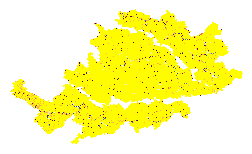

In [14]:
for block_info in blocks_info:
    print(f"Processing block: {block_info['block']}")
    generate_stac_for_block(block_info)
    
generate_root_catalog(blocks_info, base_dir="../data/", corestack_dir="../data/CorestackCatalogs")